In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [98]:
house_data = pd.read_csv("../data/kc_house_data.csv")
house_data.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [30]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

1. Before building the model, start by looking at a scatterplot of price vs. the square footage of living space. What do you find? How strong does the relationship appear to be?

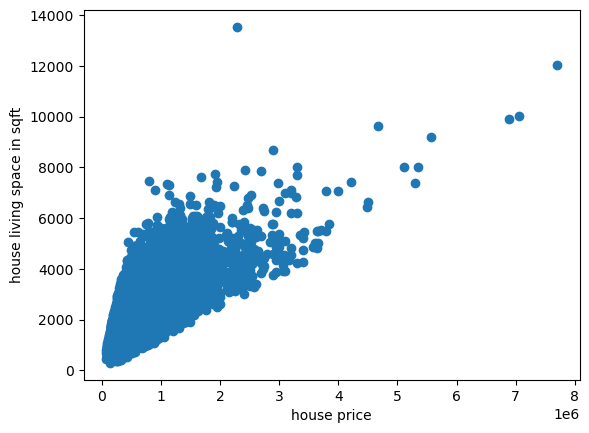

In [31]:
plt.scatter(house_data["price"], house_data["sqft_living"])
plt.xlabel('house price')
plt.ylabel('house living space in sqft')
plt.show()

* The house price and living space in sqft are positively correlated. when the sqft increses the housing price also tend to increase but it also depends on various other factors.

2. Create a DataFrame, X, which contains one column, the sqft_living space and a Series, y, which contains the target variable.

One of the most important concepts when it comes to machine learning is that the only performance we care about is how well the model predicts on data that it has not seen yet.

One way to accomplish this is through setting aside a portion of the data as a **test set** and to train the model on the remaining portion.

In [32]:
X = house_data[['sqft_living']] #used 2 squered brackets to make sure the result in pandas data frame rather than a series
y= house_data['price']

#initialize the model
house_model = LinearRegression()
#train the model
house_model.fit(X, y)

print(X.describe())

3. Use the [train_test_split function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to create a training and a test set from X and y. Name the resulting pieces X_train, X_test, y_train, and y_test. When you do this, use 30% of the data in the test set. Also, use the random_state parameter so that we can compare model performance as we change the way we build our model.

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3,train_size = 0.7 , random_state = 100)

4. Import the [LinearRegression class](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) from the linear_model module. Then create a linear regression instance and fit it to the training data.

In [90]:
ln_house_model = LinearRegression(fit_intercept=True).fit(X_train,y_train)

In [91]:
ln_house_model.score(X,y)

0.4928373851268174

5. What is the intercept term, and what is the coefficient for sqft_living? How can you interpret how the model is using sqft_living to make predictions? Hint: You can get these values by looking at the .intercept_ and .coef_ attributes of the fit model.

In [92]:
ln_house_model.coef_

array([279.73039149])

In [93]:
ln_house_model.intercept_

np.float64(-40514.31944705092)

* The coefficient of a this model tells that when the additional 1 square foot of increase in living space the model predicts an avg  increase of 279.95945438 in the house price.
* Intercept represents predicted price of a house when the sqft is zero. While house with zero sqft is not possible, so the intercept act as a baseline and starting point for the regression line, helping to adjust the overall price level.

In [56]:
#the model is using sqft_living to make predictions
price = Intercept + (279.95945438) * (sqft_living)

NameError: name 'Intercept' is not defined

In [94]:
#let's take sqft living is 1180 and check the house price
price1 = 1180 * 279.73039149 +(-40514.31944705092)
price1

289567.5425111491

In [95]:
#let's take sqft living is 770 and check the house price
price2 = 770 * 279.73039149 +(-40514.31944705092)
price2

174878.08200024907

The next step is to evaluate how well the model does on the unseen data. 

6. Use the predict method to generate a set of predictions on X_test. Save the results to y_pred. Question: What type of object is y_pred? What is its shape and how does it compare to y_test?

In [100]:
y_pred = ln_house_model.predict(X_test)

* y_pred is an 1D array with a length equal to number of samples in X_test.
* y_test contains the actual correct labels for test data, y_pred contains the model predictions. 


Now, we can evaluate how well the model did. There are a number of different metrics that could be used. Let's look at five of them, mean squared error, root mean squared error, mean absolute error, mean absolute percentage error, and R^2 score. For more information on these metrics, see https://developer.nvidia.com/blog/a-comprehensive-overview-of-regression-evaluation-metrics/.

7. Calculate each metric on the test set. For each one, interpret what the number means.

In [101]:
mse = mean_squared_error(y_test,y_pred)

67101265833.10636